# Top-2 Causal Phrasings Across Model Training Stages

The two prompt phrasings with the strongest causal pointing-game effect from
`prompt_phrasing_vis_head_vs_causal.ipynb`'s 10-phrasing sweep — **`find`** and
**`identify`** (tied at 64.3% steered accuracy, p=4.3e-26) — replayed across the three
training stages of the same base model:

- **base** — `Qwen/Qwen2-VL-7B` (pretrained, no instruction tuning)
- **instruct** — `Qwen/Qwen2-VL-7B-Instruct`
- **agentic** — `ByteDance-Seed/UI-TARS-7B-DPO` (GUI-agent fine-tune of the same base)

For each (model, phrasing) pair: discover Vis-Heads on ImageNet-grid with that
phrasing, then run the forced-choice causal pointing-game evaluation. Baseline and
location-cue conditions are shared *within* a model (they don't depend on phrasing)
but recomputed *per* model (a model's own baseline competence differs).

In [1]:
%matplotlib inline
import re
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "vis_head").exists():
    raise RuntimeError("Run this notebook from the repository root (vis-head/).")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from tqdm.auto import tqdm

from vis_head.common import DEFAULT_SEED, dump_json, make_output_paths
from vis_head.vir import aggregate_region_attention, collect_last_query_attentions, rank_heads_by_score
from vis_head.imagenet_grid import DEFAULT_IMAGENET_ROOT, mcq_prompt, PROMPT_TEMPLATES, list_val_class_dirs, load_class_names, sample_grid
from vis_head.judge import bootstrap_ci
from vis_head.modeling import decode_generated_text, find_image_token_range, load_model_and_processor, model_dims, prepare_inputs, run_generation
from vis_head.regions import assign_grid_cells_to_tokens, region_positions_from_ids
from vis_head.steering import group_heads_by_layer, intervention_positions, make_static_attention_mask_hook, register_mask_hooks, remove_handles


In [2]:
# ----------------------------- configuration -----------------------------
MODELS = {
    "base": "Qwen/Qwen2-VL-7B",
    "instruct": "Qwen/Qwen2-VL-7B-Instruct",
    "agentic": "ByteDance-Seed/UI-TARS-7B-DPO",
}
PHRASINGS = {
    "find": lambda name: PROMPT_TEMPLATES["find"].format(name=name),
    "identify": lambda name: PROMPT_TEMPLATES["identify"].format(name=name),
}
DEVICE = "cuda:0"
SEED = DEFAULT_SEED

ROWS, COLS = 2, 2
N_CELLS = ROWS * COLS
CELL_SIZE = 256
N_DISCOVERY_SAMPLES = 600
TOP_K_HEADS = 15
N_MCQ_SAMPLES = 600
N_OPTIONS = 4
CAUSAL_MAX_NEW_TOKENS = 6
OPTION_LETTERS = ["A", "B", "C", "D"][:N_OPTIONS]

imagenet_class_dirs = list_val_class_dirs(DEFAULT_IMAGENET_ROOT)
imagenet_class_names = load_class_names(DEFAULT_IMAGENET_ROOT)

print(f"Models: {list(MODELS.keys())}")
print(f"Phrasings: {list(PHRASINGS.keys())}")


# Base (Qwen2-VL-7B, no instruction tuning) may not ship a usable chat template of
# its own, so `processor.apply_chat_template(...)` silently fails to expand the
# image placeholder for it (same issue solved in compare_base_vs_instruct_vis_heads.ipynb):
# render the template ONCE using the Instruct checkpoint's processor, and feed that
# exact text to every model's own processor. All three share the same tokenizer/vocab,
# so this also gives identical token ids across models -- isolating the effect of the
# weights, not a difference in prompt formatting.
from transformers import AutoProcessor

_template_processor = AutoProcessor.from_pretrained(MODELS["instruct"])


def render_chat_text(prompt: str) -> str:
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}]
    rendered = _template_processor.apply_chat_template([messages], tokenize=False, add_generation_prompt=True)
    return rendered[0] if isinstance(rendered, list) else rendered


def prepare_inputs_any(processor, image, prompt: str, device: str):
    text = render_chat_text(prompt)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    return inputs.to(device)

Models: ['base', 'instruct', 'agentic']
Phrasings: ['find', 'identify']


## Discovery + causal helper functions

Same design as the phrasing sweep: `discover_vis_head_scores` for Part-1-style
attention scoring, `build_mcq_sample`/`run_mcq` for the forced-choice pointing-game
evaluation (bbox location-cue baseline included, same as before).

In [3]:
def discover_vis_head_scores(model, processor, n_layers, n_heads, spatial_merge, prompt_fn, label, seed):
    rng = np.random.RandomState(seed)
    raw_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    valid = 0
    for _ in tqdm(range(N_DISCOVERY_SAMPLES), desc=f"[{label}]", leave=False):
        grid = sample_grid(rows=ROWS, cols=COLS, cell_size=CELL_SIZE, rng=rng,
                            class_dirs=imagenet_class_dirs, class_names=imagenet_class_names)
        target_cell = int(rng.randint(N_CELLS))
        prompt = prompt_fn(grid.cell_names[target_cell])
        try:
            inputs = prepare_inputs_any(processor, grid.grid, prompt, DEVICE)
            region_ids, _ = assign_grid_cells_to_tokens(
                image_grid_thw=inputs["image_grid_thw"], rows=ROWS, cols=COLS, spatial_merge=spatial_merge)
            attn_at_query = collect_last_query_attentions(model, inputs)
            region_attention = aggregate_region_attention(
                attn_at_query=attn_at_query, inputs=inputs, processor=processor, region_ids=region_ids, n_regions=N_CELLS)
            raw = region_attention[:, :, target_cell]
            raw_sum += raw
            valid += 1
        except Exception as exc:
            print(f"Skipping grid: {exc}")
    print(f"  [{label:>10s}] valid={valid}/{N_DISCOVERY_SAMPLES}  mean score={raw_sum.mean() / max(valid, 1):.5f}")
    return (raw_sum / max(valid, 1)).astype(np.float32)


def build_mcq_sample(rng):
    grid = sample_grid(rows=ROWS, cols=COLS, cell_size=CELL_SIZE, rng=rng,
                        class_dirs=imagenet_class_dirs, class_names=imagenet_class_names)
    target_cell = int(rng.randint(N_CELLS))
    correct_name = grid.cell_names[target_cell]
    other_names = [n for i, n in enumerate(grid.cell_names) if i != target_cell]
    n_distractors = min(N_OPTIONS - 1, len(other_names))
    distractor_idx = rng.choice(len(other_names), size=n_distractors, replace=False)
    distractors = [other_names[i] for i in distractor_idx]
    options = [correct_name] + distractors
    order = rng.permutation(len(options))
    options = [options[i] for i in order]
    correct_letter = OPTION_LETTERS[int(np.where(order == 0)[0][0])]
    option_lines = "  ".join(f"{letter}) {name}" for letter, name in zip(OPTION_LETTERS[:len(options)], options))
    prompt = f"Which of the following is shown in this image? {option_lines}. Answer with only the letter."
    location_prompt = mcq_prompt(target_cell + 1, ROWS, COLS, options, OPTION_LETTERS[:len(options)])
    return {"grid": grid, "target_cell": target_cell, "options": options, "correct_letter": correct_letter,
            "prompt": prompt, "location_prompt": location_prompt}


def extract_letter(text, valid_letters):
    match = re.search(r"\b([" + "".join(valid_letters) + r"])\b", text.upper())
    return match.group(1) if match else None


def run_mcq(model, processor, n_heads, spatial_merge, sample, heads_by_layer, prompt_key="prompt"):
    inputs = prepare_inputs_any(processor, sample["grid"].grid, sample[prompt_key], DEVICE)
    prompt_length = int(inputs["input_ids"].shape[1])
    handles = []
    if heads_by_layer is not None:
        img_start, img_end = find_image_token_range(inputs, processor)
        region_ids, _ = assign_grid_cells_to_tokens(
            image_grid_thw=inputs["image_grid_thw"], rows=ROWS, cols=COLS, spatial_merge=spatial_merge)
        positions = region_positions_from_ids(img_start=img_start, region_ids=region_ids, n_regions=N_CELLS)
        target_positions = positions[sample["target_cell"]]
        other_positions = [p for i in range(N_CELLS) if i != sample["target_cell"] for p in positions[i]]
        suppress_positions, boost_positions, pad = intervention_positions(
            mode="boost_suppress", target_positions=target_positions, other_image_positions=other_positions,
            img_start=img_start, img_end=img_end, prompt_length=prompt_length)
        hook_by_layer = {
            layer_idx: make_static_attention_mask_hook(
                head_indices=heads, suppress_positions=suppress_positions, boost_positions=boost_positions,
                n_query_heads=n_heads, device=DEVICE, decode_only=False, pad_with_suppress=pad)
            for layer_idx, heads in heads_by_layer.items()
        }
        handles = register_mask_hooks(model, hook_by_layer)
    try:
        sequences = run_generation(model=model, inputs=inputs, max_new_tokens=CAUSAL_MAX_NEW_TOKENS)
    finally:
        remove_handles(handles)
    text = decode_generated_text(processor, sequences, prompt_length)
    valid_letters = OPTION_LETTERS[: len(sample["options"])]
    predicted = extract_letter(text, valid_letters)
    return {"text": text, "predicted": predicted, "correct": predicted == sample["correct_letter"]}


## Run: discovery + causal eval, per model, per phrasing

One model load per stage (sequential -- one 7B checkpoint in GPU memory at a time).

In [4]:
results = {}   # (model_tag, phrasing) -> dict
for model_tag, model_id in MODELS.items():
    print(f"\n=== Loading {model_id} ({model_tag}) ===")
    model, processor = load_model_and_processor(model_id=model_id, device=DEVICE)
    n_layers, n_heads, spatial_merge = model_dims(model)
    print(f"{n_layers} layers x {n_heads} heads")

    vis_head_scores = {}
    vis_head_ranked = {}
    for tag, fn in PHRASINGS.items():
        scores = discover_vis_head_scores(model, processor, n_layers, n_heads, spatial_merge, fn, f"{model_tag}/{tag}", seed=SEED + 100)
        vis_head_scores[tag] = scores
        vis_head_ranked[tag] = rank_heads_by_score(scores)

    mcq_rng = np.random.RandomState(SEED + 555)
    mcq_samples = [build_mcq_sample(mcq_rng) for _ in range(N_MCQ_SAMPLES)]

    shared_baseline_res, shared_location_res = [], []
    for sample in tqdm(mcq_samples, desc=f"MCQ [{model_tag}] baseline+location", leave=False):
        shared_baseline_res.append(run_mcq(model, processor, n_heads, spatial_merge, sample, None, "prompt"))
        shared_location_res.append(run_mcq(model, processor, n_heads, spatial_merge, sample, None, "location_prompt"))
    b_acc = np.mean([r["correct"] for r in shared_baseline_res])
    l_acc = np.mean([r["correct"] for r in shared_location_res])
    print(f"  [{model_tag}] baseline={b_acc:.3f}  location-cue={l_acc:.3f}")

    for tag, fn in PHRASINGS.items():
        heads_by_layer = group_heads_by_layer([(r["layer"], r["head"]) for r in vis_head_ranked[tag][:TOP_K_HEADS]])
        steered_res = []
        for sample in tqdm(mcq_samples, desc=f"MCQ [{model_tag}/{tag}] steered", leave=False):
            steered_res.append(run_mcq(model, processor, n_heads, spatial_merge, sample, heads_by_layer, "prompt"))
        s_acc = np.mean([r["correct"] for r in steered_res])
        print(f"  [{model_tag}/{tag}] steered={s_acc:.3f}")
        results[(model_tag, tag)] = {
            "vis_head_scores": vis_head_scores[tag], "baseline": shared_baseline_res,
            "location_cue": shared_location_res, "steered": steered_res,
        }

    del model, processor
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()



=== Loading Qwen/Qwen2-VL-7B (base) ===


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

28 layers x 28 heads


...

  [agentic] baseline=0.262  location-cue=0.928


MCQ [agentic/find] steered:   0%|          | 0/600 [00:00<?, ?it/s]

  [agentic/find] steered=0.393


MCQ [agentic/identify] steered:   0%|          | 0/600 [00:00<?, ?it/s]

  [agentic/identify] steered=0.310


## Results table

In [5]:
from sklearn.metrics import f1_score


def macro_f1(results_list, samples_list):
    """Macro-F1 over the option letters (A/B/C/D), treating an unparsed (None)
    prediction as its own wrong-answer class so it still counts against the model
    rather than being silently dropped."""
    y_true = [s["correct_letter"] for s in samples_list]
    y_pred = [r["predicted"] if r["predicted"] is not None else "UNPARSED" for r in results_list]
    labels = sorted(set(y_true) | set(y_pred))
    return float(f1_score(y_true, y_pred, labels=labels, average="macro"))


def mcnemar_p(cond_a, cond_b):
    b = sum(1 for a, c in zip(cond_a, cond_b) if not a["correct"] and c["correct"])
    c = sum(1 for a, c in zip(cond_a, cond_b) if a["correct"] and not c["correct"])
    n_discordant = b + c
    if n_discordant == 0:
        return float("nan")
    stat = (abs(b - c) - 1) ** 2 / n_discordant
    return float(stats.chi2.sf(stat, df=1))


outputs = make_output_paths("top2_phrasings_across_stages")
rows_summary = []
print(f"{'model':>10s}  {'phrasing':>10s}  {'vh mean':>9s}  {'vh median':>10s}  {'vh std':>9s}  "
      f"{'baseline':>9s}  {'loc-cue':>9s}  {'steered':>9s}  {'f1 base':>9s}  {'f1 loc':>9s}  {'f1 steer':>9s}  "
      f"{'p(s,b)':>10s}  {'p(s,l)':>10s}")
for model_tag in MODELS:
    for tag in PHRASINGS:
        r = results[(model_tag, tag)]
        scores_flat = r["vis_head_scores"].reshape(-1)
        b_acc = np.mean([x["correct"] for x in r["baseline"]])
        l_acc = np.mean([x["correct"] for x in r["location_cue"]])
        s_acc = np.mean([x["correct"] for x in r["steered"]])
        f1_base = macro_f1(r["baseline"], mcq_samples)
        f1_loc = macro_f1(r["location_cue"], mcq_samples)
        f1_steer = macro_f1(r["steered"], mcq_samples)
        p_sb = mcnemar_p(r["baseline"], r["steered"])
        p_sl = mcnemar_p(r["location_cue"], r["steered"])
        print(f"{model_tag:>10s}  {tag:>10s}  {scores_flat.mean():9.5f}  {np.median(scores_flat):10.5f}  "
              f"{scores_flat.std():9.5f}  {b_acc:9.3f}  {l_acc:9.3f}  {s_acc:9.3f}  "
              f"{f1_base:9.3f}  {f1_loc:9.3f}  {f1_steer:9.3f}  {p_sb:10.3e}  {p_sl:10.3e}")
        rows_summary.append({"model": model_tag, "phrasing": tag, "vh_mean": float(scores_flat.mean()),
                              "vh_median": float(np.median(scores_flat)), "vh_std": float(scores_flat.std()),
                              "baseline_acc": float(b_acc), "location_cue_acc": float(l_acc),
                              "steered_acc": float(s_acc), "f1_baseline": f1_base, "f1_location_cue": f1_loc,
                              "f1_steered": f1_steer, "p_steer_vs_base": p_sb, "p_steer_vs_loc": p_sl})

dump_json(outputs.logs_dir / "top2_phrasings_across_stages_summary.json", rows_summary)

     model    phrasing    vh mean   vh median     vh std   baseline    loc-cue    steered    f1 base     f1 loc   f1 steer      p(s,b)      p(s,l)
      base        find    0.03193     0.02096    0.03727      0.197      0.057      0.225      0.113      0.085      0.082   6.467e-02   6.144e-17
      base    identify    0.03091     0.01981    0.03845      0.197      0.057      0.238      0.113      0.085      0.107   9.237e-03   8.934e-19
  instruct        find    0.03802     0.02635    0.04001      0.217      0.952      0.260      0.208      0.951      0.222   1.331e-02   8.139e-92
  instruct    identify    0.04198     0.03068    0.04104      0.217      0.952      0.275      0.208      0.951      0.238   6.329e-04   7.407e-90
   agentic        find    0.04736     0.03121    0.05424      0.262      0.928      0.393      0.197      0.745      0.371   1.582e-09   4.498e-70
   agentic    identify    0.04909     0.03387    0.05177      0.262      0.928      0.310      0.197      0.745      0

PosixPath('/mnt/abka03/Projects/vis-head/logs/top2_phrasings_across_stages/top2_phrasings_across_stages_summary.json')

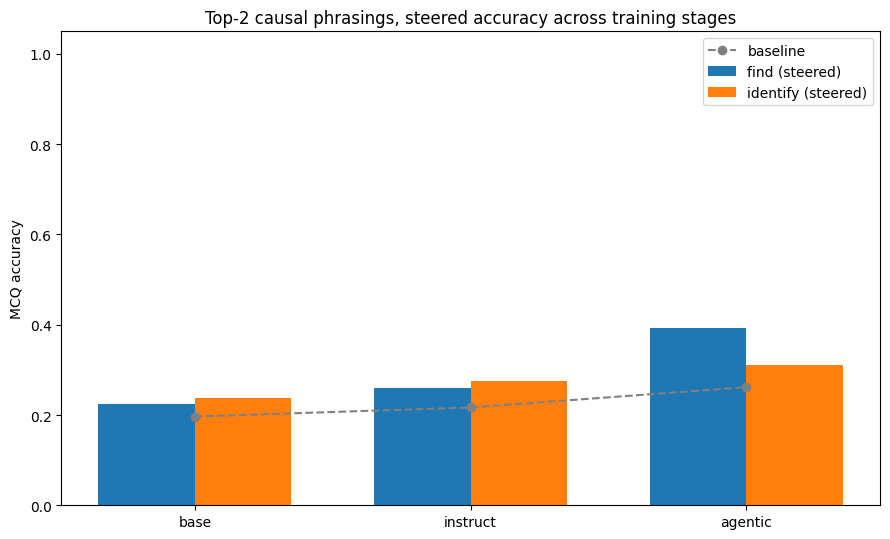

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(MODELS))
width = 0.35
colors = {"find": "tab:blue", "identify": "tab:orange"}
for i, tag in enumerate(PHRASINGS):
    accs = [np.mean([r["correct"] for r in results[(m, tag)]["steered"]]) for m in MODELS]
    offset = (i - 0.5) * width
    ax.bar(x + offset, accs, width, label=f"{tag} (steered)", color=colors[tag])
baseline_accs = [np.mean([r["correct"] for r in results[(m, "find")]["baseline"]]) for m in MODELS]
ax.plot(x, baseline_accs, "o--", color="gray", label="baseline")
ax.set_xticks(x); ax.set_xticklabels(list(MODELS.keys()))
ax.set_ylabel("MCQ accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Top-2 causal phrasings, steered accuracy across training stages")
ax.legend()
plt.tight_layout()
plt.savefig(outputs.figures_dir / "top2_phrasings_across_stages.pdf", bbox_inches="tight")
plt.show()
